# Sentiment Evaluation

**Goal:** compare the project sentiment model (TF-IDF + LogisticRegression, trained on UCI Drug Reviews per Phase 4.1) against two `sklearn.dummy.DummyClassifier` baselines on the held-out Drug Reviews **test** split.

**Compared models:**

1. **Trained**: `src.pipeline.sentiment.predict_batch()` (project wrapper around the joblib-dumped pipeline)
2. **`DummyClassifier(strategy="most_frequent")`**: predicts the single most common training class on every row
3. **`DummyClassifier(strategy="stratified")`**: samples a label per row using training class frequencies

**Metrics:** accuracy (lead), per-class Precision / Recall / F1, macro-F1, weighted-F1. Confusion matrix printed for the trained model only (dummy CMs are mechanical and add no signal).


In [1]:
import sys
import time
from collections import Counter
from pathlib import Path

import pandas as pd

# Project import path: notebooks/ lives one level under the repo root
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)

from src.utils.config import RESULTS_DIR, SENTIMENT_TRAINING_DATA
from src.pipeline import (
    sentiment as sentiment_wrapper,
)  # same wrapper that runs in the UI
from src.pipeline.preprocessing import (
    preprocess,
)  # training applied this; eval must match

c:\Users\Admin\anaconda3\Lib\site-packages\spacy\util.py:910: UserWarning: [W095] Model 'en_core_web_sm' (3.8.0) was trained with spaCy v3.8.0 and may not be 100% compatible with the current version (3.7.5). If you see errors or degraded performance, download a newer compatible model or retrain your custom model with the current spaCy version. For more details and available updates, run: python -m spacy validate
  warnings.warn(warn_msg)


In [ ]:
# Rating to class binning. Identical to scripts/train_sentiment.py so the trained
# model is evaluated against the same label scheme it learned from.
def bin_rating(r: int) -> str:
    if r <= 4:
        return "negative"
    if r <= 6:
        return "neutral"
    return "positive"


# Load the pre split cleaned files. We need TRAIN to fit the dummy baselines
# (so they learn the training class prior, not the test one, no leakage).
train_df = (
    pd.read_csv(SENTIMENT_TRAINING_DATA["train"])
    .dropna(subset=["review", "rating"])
    .copy()
)
test_df = (
    pd.read_csv(SENTIMENT_TRAINING_DATA["test"])
    .dropna(subset=["review", "rating"])
    .copy()
)

train_df["label"] = train_df["rating"].astype(int).map(bin_rating)
test_df["label"] = test_df["rating"].astype(int).map(bin_rating)

print(f"Train: {len(train_df):,} rows")
print(f"Test:  {len(test_df):,} rows")

Train: 110,811 rows
Test:  46,108 rows


## Inspecting the test set

Quick look at the shape and label distribution before evaluating.


In [ ]:
# First 10 rows. Shows the raw fields the eval will consume plus the binned label.
preview = pd.DataFrame(
    [
        {
            "patient_id": int(r["patient_id"]),
            "drug": r["drugName"],
            "condition": r["condition"],
            "rating": int(r["rating"]),
            "label": r["label"],
            "review": (
                (str(r["review"])[:80] + "...")
                if len(str(r["review"])) > 80
                else str(r["review"])
            ),
        }
        for _, r in test_df.head(10).iterrows()
    ]
)
preview

,patient_id,drug,condition,rating,label,review
0,163740,Mirtazapine,depression,10,positive,"""i've tried a few antidepressants over the yea..."
1,206473,Mesalamine,"crohn's disease, maintenance",8,positive,"""my son has crohn's disease and has done very ..."
2,39293,Contrave,weight loss,9,positive,"""contrave combines drugs that were used for al..."
3,97768,Cyclafem 1 / 35,birth control,9,positive,"""i have been on this birth control for one cyc..."
4,208087,Zyclara,keratosis,4,negative,"""4 days in on first 2 weeks. using on arms an..."
5,215892,Copper,birth control,6,neutral,"""i've had the copper coil for about 3 months n..."
6,169852,Amitriptyline,migraine prevention,9,positive,"""this has been great for me. i've been on it f..."
7,23295,Methadone,opiate withdrawal,7,positive,"""ive been on methadone for over ten years and ..."
8,71428,Levora,birth control,2,negative,"""i was on this pill for almost two years. it d..."
9,196802,Paroxetine,hot flashes,1,negative,"""holy hell is exactly how i feel. i had been t..."


In [ ]:
# Raw rating distribution (1 to 10). Tells the reader how skewed the source ratings
# are before they get binned into 3 classes. Drug Reviews is famously top-heavy
# (lots of 9s and 10s).
rating_dist = test_df["rating"].astype(int).value_counts().sort_index()
print(rating_dist.to_string())
print(
    f"\nmean rating: {test_df['rating'].mean():.2f}   median: {test_df['rating'].median():.0f}"
)

rating
1      6034
2      2028
3      1931
4      1452
5      2394
6      1860
7      2738
8      5423
9      7972
10    14276

mean rating: 6.98   median: 8


In [ ]:
# Post binning class distribution. TRAIN and TEST side by side.
# The TRAIN column is what the majority/stratified dummies will reflect; the TEST
# column is what all three models are scored against.
dist = pd.DataFrame(
    {
        "train": train_df["label"]
        .value_counts()
        .reindex(["negative", "neutral", "positive"]),
        "test": test_df["label"]
        .value_counts()
        .reindex(["negative", "neutral", "positive"]),
    }
)
dist["train_share"] = (dist["train"] / dist["train"].sum()).map(lambda x: f"{x:.1%}")
dist["test_share"] = (dist["test"] / dist["test"].sum()).map(lambda x: f"{x:.1%}")
dist

,train,test,train_share,test_share
label,,,,
negative,27103,11445,24.5%,24.8%
neutral,10070,4254,9.1%,9.2%
positive,73638,30409,66.5%,66.0%


In [ ]:
# 3 sample reviews with their rating and binned label. Gives the reader an intuition
# for what the model is being asked to discriminate (negative vs neutral vs positive prose).
for _, r in test_df.head(3).iterrows():
    print(
        f"[{r['label'].upper():8}] rating={int(r['rating']):>2}  drug={r['drugName']}"
    )
    print(f"  {str(r['review'])[:200]}{'...' if len(str(r['review'])) > 200 else ''}")
    print()

[POSITIVE] rating=10  drug=Mirtazapine
  "i've tried a few antidepressants over the years (citalopram, fluoxetine, amitriptyline), but none of those helped with my depression, insomnia & anxiety. my doctor suggested and changed me onto 45mg ...

[POSITIVE] rating= 8  drug=Mesalamine
  "my son has crohn's disease and has done very well on the asacol.  he has no complaints and shows no side effects.  he has taken as many as nine tablets per day at one time.  i've been very happy with...

[POSITIVE] rating= 9  drug=Contrave
  "contrave combines drugs that were used for alcohol, smoking, and opioid cessation. people lose weight on it because it also helps control over-eating. i have no doubt that most obesity is caused from...



## Predictions

Three predictors:

- **Trained model**: through the project wrapper, on text that has been run through `preprocess()` (the same step training applied). This matches Streamlit pipeline behavior end to end.
- **Dummy (most_frequent)**: fit on training labels, predicts the single most common training class for every test row.
- **Dummy (stratified)**: fit on training labels, samples a label per test row using training class proportions.


In [7]:
# Preprocess test reviews ONCE. Avoids paying the regex/abbreviation cost three
# times. Training applied preprocess() to every row before fitting, so the trained
# model expects the same shape of text at inference time.
t0 = time.perf_counter()
test_texts = [preprocess(t) for t in test_df["review"].astype(str).tolist()]
t_preprocess = time.perf_counter() - t0
print(f"preprocess: {t_preprocess:.1f}s on {len(test_texts):,} reviews")

y_true = test_df["label"].tolist()

preprocess: 1.5s on 46,108 reviews


In [8]:
# Trained model: one batched call to the project wrapper.
# predict_batch returns dicts {label, score}; we only need the labels for accuracy/F1.
t0 = time.perf_counter()
trained_preds = [p["label"] for p in sentiment_wrapper.predict_batch(test_texts)]
t_trained = time.perf_counter() - t0
print(f"trained:    {t_trained:.1f}s")

# Both dummies need an X argument but ignore it (they only look at y during fit).
# We pass a list of dummy zeros of the right length so sklearn's shape check is satisfied.
X_train_dummy = [[0]] * len(train_df)
X_test_dummy = [[0]] * len(test_df)
y_train = train_df["label"].tolist()

# strategy="most_frequent" -> majority-class baseline. The single class with the highest count
# in y_train is predicted for every test row.
t0 = time.perf_counter()
dummy_most = DummyClassifier(strategy="most_frequent", random_state=0)
dummy_most.fit(X_train_dummy, y_train)
most_preds = dummy_most.predict(X_test_dummy).tolist()
t_most = time.perf_counter() - t0
print(
    f"dummy most_frequent: {t_most:.2f}s  (always predicts {dummy_most.classes_[dummy_most.class_prior_.argmax()]!r})"
)

# strategy="stratified" -> samples a label per row from the training class distribution.
# Fixed random_state so the eval is reproducible across runs.
t0 = time.perf_counter()
dummy_strat = DummyClassifier(strategy="stratified", random_state=0)
dummy_strat.fit(X_train_dummy, y_train)
strat_preds = dummy_strat.predict(X_test_dummy).tolist()
t_strat = time.perf_counter() - t0
print(f"dummy stratified:    {t_strat:.2f}s")

trained:    4.8s
dummy most_frequent: 0.02s  (always predicts 'positive')
dummy stratified:    0.02s


## Per-model metrics

For each predictor: accuracy, per-class Precision / Recall / F1, then macro-F1 (unweighted average across classes, the honest number on imbalanced data) and weighted-F1 (weighted by class size in the test set, tracks accuracy more closely).


In [9]:
LABELS = ["negative", "neutral", "positive"]


def report(name: str, y_pred):
    """Print accuracy + per-class P/R/F1 + macro/weighted F1 for one predictor."""
    acc = accuracy_score(y_true, y_pred)
    # precision_recall_fscore_support returns per-label arrays in the order given by `labels`
    p, r, f, support = precision_recall_fscore_support(
        y_true, y_pred, labels=LABELS, zero_division=0
    )
    macro_f1 = f1_score(y_true, y_pred, average="macro", labels=LABELS, zero_division=0)
    weighted_f1 = f1_score(
        y_true, y_pred, average="weighted", labels=LABELS, zero_division=0
    )

    print(f"=== {name} ===")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  {'class':<10}{'Precision':>12}{'Recall':>10}{'F1':>10}{'support':>10}")
    for i, lbl in enumerate(LABELS):
        print(f"  {lbl:<10}{p[i]:>12.4f}{r[i]:>10.4f}{f[i]:>10.4f}{support[i]:>10,}")
    print(f"  macro-F1   : {macro_f1:.4f}")
    print(f"  weighted-F1: {weighted_f1:.4f}")
    print()

    # Return per-class F1s so the chart cell at the bottom can use them without re-computing
    return {
        "accuracy": acc,
        "per_class_f1": dict(zip(LABELS, f)),
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
    }


metrics_trained = report("Trained (TF-IDF + LogReg)", trained_preds)
metrics_most = report("DummyClassifier(most_frequent)", most_preds)
metrics_strat = report("DummyClassifier(stratified)", strat_preds)

=== Trained (TF-IDF + LogReg) ===
  Accuracy: 0.8302
  class        Precision    Recall        F1   support
  negative        0.7688    0.8246    0.7957    11,445
  neutral         0.4484    0.6335    0.5251     4,254
  positive        0.9397    0.8598    0.8980    30,409
  macro-F1   : 0.7396
  weighted-F1: 0.8382

=== DummyClassifier(most_frequent) ===
  Accuracy: 0.6595
  class        Precision    Recall        F1   support
  negative        0.0000    0.0000    0.0000    11,445
  neutral         0.0000    0.0000    0.0000     4,254
  positive        0.6595    1.0000    0.7948    30,409
  macro-F1   : 0.2649
  weighted-F1: 0.5242

=== DummyClassifier(stratified) ===
  Accuracy: 0.5077
  class        Precision    Recall        F1   support
  negative        0.2446    0.2401    0.2423    11,445
  neutral         0.0922    0.0882    0.0901     4,254
  positive        0.6585    0.6672    0.6628    30,409
  macro-F1   : 0.3318
  weighted-F1: 0.5056



In [10]:
# Confusion matrix for the trained model only. Shows where errors actually fall
# (e.g. is neutral being absorbed into positive? is negative ever predicted at all?).
# Dummy CMs are mechanical: most_frequent has all mass in one column, stratified
# spreads by class prior. Printing them adds no information beyond the per-class
# table above.
cm = confusion_matrix(y_true, trained_preds, labels=LABELS)
cm_df = pd.DataFrame(
    cm, index=[f"true_{l}" for l in LABELS], columns=[f"pred_{l}" for l in LABELS]
)
print("Trained model confusion matrix")
print(cm_df.to_string())

Trained model confusion matrix
               pred_negative  pred_neutral  pred_positive
true_negative           9437          1092            916
true_neutral             797          2695            762
true_positive           2041          2223          26145


## Comparison chart

Per-class F1 grouped bars: 3 classes (negative / neutral / positive), 3 bars per class (trained / most_frequent / stratified). Saved as a PNG for the report.


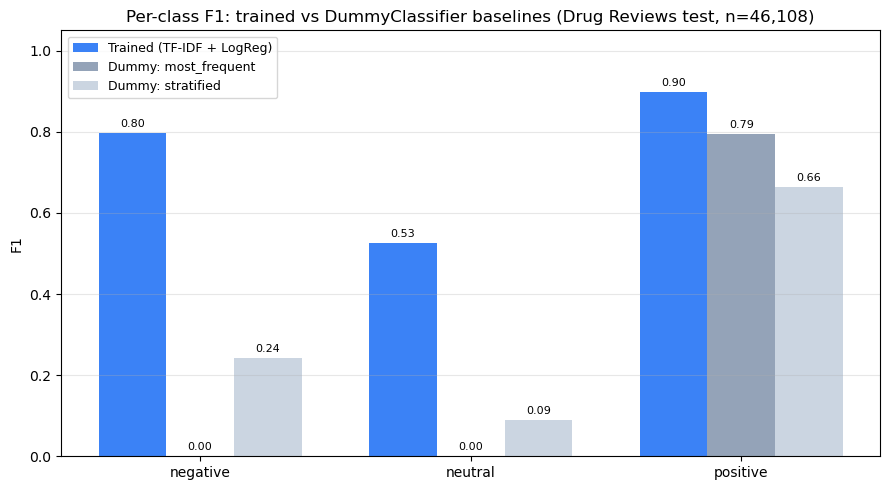

In [11]:
import matplotlib.pyplot as plt

# results/ is the project's standard artifact directory
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
chart_path = RESULTS_DIR / "sentiment_eval_chart.png"

# x-axis positions: one slot per class
x_positions = list(range(len(LABELS)))
bar_width = (
    0.25  # three bars per slot -> each takes 1/3 of the slot width with a small gap
)

# Pull per-class F1 in label order so the bars line up across models
trained_f1 = [metrics_trained["per_class_f1"][l] for l in LABELS]
most_f1 = [metrics_most["per_class_f1"][l] for l in LABELS]
strat_f1 = [metrics_strat["per_class_f1"][l] for l in LABELS]

fig, ax = plt.subplots(figsize=(9, 5))

# Three bar groups, offset left/centre/right of each x position
bars_t = ax.bar(
    [i - bar_width for i in x_positions],
    trained_f1,
    bar_width,
    label="Trained (TF-IDF + LogReg)",
    color="#3b82f6",
)
bars_m = ax.bar(
    [i for i in x_positions],
    most_f1,
    bar_width,
    label="Dummy: most_frequent",
    color="#94a3b8",
)
bars_s = ax.bar(
    [i + bar_width for i in x_positions],
    strat_f1,
    bar_width,
    label="Dummy: stratified",
    color="#cbd5e1",
)

# Numeric labels on top of every bar so the reader does not have to eyeball the y axis
for group in (bars_t, bars_m, bars_s):
    for bar in group:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + 0.01,
            f"{h:.2f}",
            ha="center",
            va="bottom",
            fontsize=8,
        )

ax.set_xticks(x_positions)
ax.set_xticklabels(LABELS)
ax.set_ylim(0, 1.05)
ax.set_ylabel("F1")
ax.set_title(
    f"Per-class F1: trained vs DummyClassifier baselines (Drug Reviews test, n={len(test_df):,})"
)
ax.grid(axis="y", alpha=0.3)
ax.legend(loc="upper left", fontsize=9)

fig.tight_layout()
fig.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()